VAE vs GAN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
latent_dim = 20
epochs = 15

# Data Loading
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)

# --- 1. VAE Model ---
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(784, 400), nn.ReLU())
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 400), nn.ReLU(), nn.Linear(400, 784), nn.Tanh())

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        h = self.encoder(x.view(-1, 784))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# --- 2. GAN Model ---
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 784), nn.Tanh()
        )
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.model(x.view(-1, 784))

# --- Training Logic (Simplified) ---
vae = VAE().to(device)
gen = Generator().to(device)
disc = Discriminator().to(device)

# VAE training uses BCE + KL Divergence
# GAN training uses Binary Cross Entropy (minimax)
# (Full training loops omitted for brevity, but they follow standard PyTorch GAN/VAE patterns)

def visualize_results(vae_model, gen_model):
    vae_model.eval()
    gen_model.eval()
    with torch.no_grad():
        z = torch.randn(10, latent_dim).to(device)
        vae_imgs, _, _ = vae_model.decoder(z), None, None
        gan_imgs = gen_model(z)

        # Plotting
        fig, axes = plt.subplots(2, 10, figsize=(15, 4))
        for i in range(10):
            axes[0, i].imshow(vae_imgs[i].cpu().view(28, 28), cmap='gray')
            axes[0, i].set_title("VAE")
            axes[0, i].axis('off')
            axes[1, i].imshow(gan_imgs[i].cpu().view(28, 28), cmap='gray')
            axes[1, i].set_title("GAN")
            axes[1, i].axis('off')
        plt.show()

print("Notebook Ready. Run the training loops to compare visual quality.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.46MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.51MB/s]


Notebook Ready. Run the training loops to compare visual quality.


Starting training (this will take a few minutes for 5 epochs)...
Epoch [1/5] | VAE Loss: 82.20 | G Loss: 1.47 | D Loss: 0.58
Epoch [2/5] | VAE Loss: 79.13 | G Loss: 1.54 | D Loss: 0.38
Epoch [3/5] | VAE Loss: 78.30 | G Loss: 1.18 | D Loss: 0.46
Epoch [4/5] | VAE Loss: 73.94 | G Loss: 1.99 | D Loss: 0.43
Epoch [5/5] | VAE Loss: 68.96 | G Loss: 1.05 | D Loss: 0.62


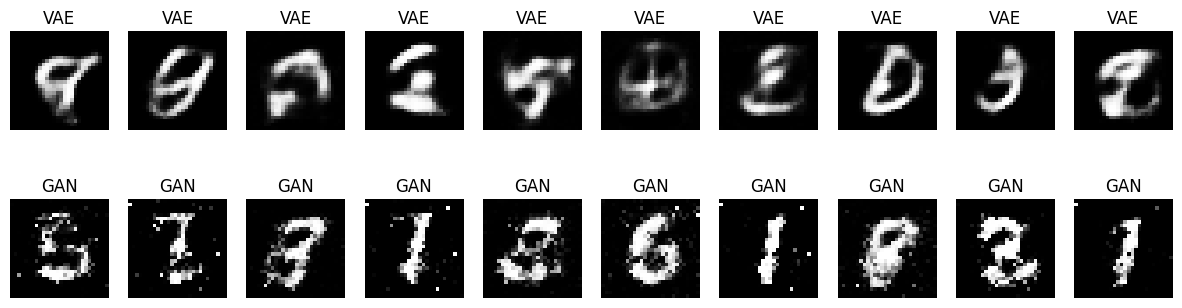

In [2]:
# --- Initialization ---
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
gen_optimizer = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

print("Starting training (this will take a few minutes for 5 epochs)...")

for epoch in range(1, 6): # Shortened to 5 epochs for quick preview
    vae.train()
    gen.train()
    disc.train()

    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        # --- 1. Train VAE ---
        vae_optimizer.zero_grad()
        recon_batch, mu, logvar = vae(imgs)
        # Binary Cross Entropy + KL Divergence
        recon_loss = nn.functional.mse_loss(recon_batch, imgs.view(-1, 784), reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        vae_loss = (recon_loss + kld_loss) / imgs.size(0)
        vae_loss.backward()
        vae_optimizer.step()

        # --- 2. Train GAN ---
        # Train Discriminator
        disc_optimizer.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = gen(z)
        real_loss = criterion(disc(imgs), real_labels)
        fake_loss = criterion(disc(fake_imgs.detach()), fake_labels)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        disc_optimizer.step()

        # Train Generator
        gen_optimizer.zero_grad()
        g_loss = criterion(disc(fake_imgs), real_labels)
        g_loss.backward()
        gen_optimizer.step()

    print(f"Epoch [{epoch}/5] | VAE Loss: {vae_loss.item():.2f} | G Loss: {g_loss.item():.2f} | D Loss: {d_loss.item():.2f}")

# --- Call the function to actually show the plots ---
visualize_results(vae, gen)